# Fixed-Point vs Floating-Point: FIR Filter Comparison
**Data Centric Architectures — Assignment 2**

In this notebook we simulate a simple FIR low-pass filter using four different number representations and compare the error each one introduces compared to a float64 reference.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter

## 2. Signal Generation

We create a synthetic signal made of a clean 50 Hz sine wave plus two sources of noise:
- A 200 Hz sine wave (high-frequency interference)
- Random Gaussian noise

The goal of the FIR filter is to remove the noise and recover the 50 Hz signal.

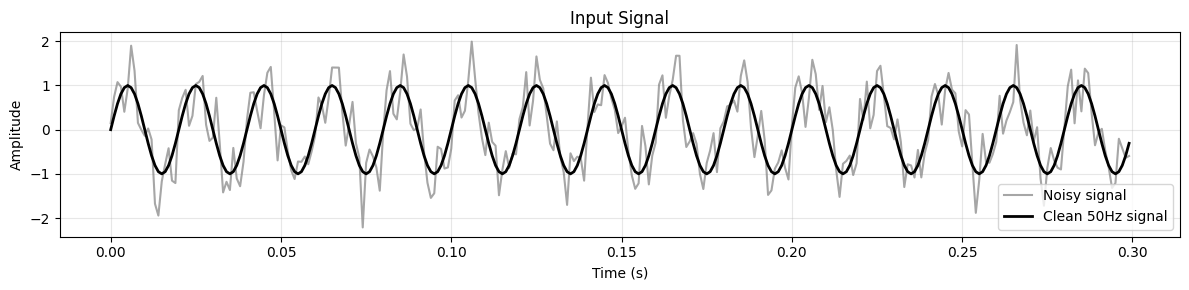

In [2]:
np.random.seed(42)  # for reproducibility

fs = 1000          # sampling frequency in Hz
duration = 1.0     # 1 second
t = np.arange(0, duration, 1/fs)

signal_clean = np.sin(2 * np.pi * 50 * t)
noise = 0.5 * np.sin(2 * np.pi * 200 * t) + 0.3 * np.random.randn(len(t))
signal_noisy = signal_clean + noise

# Quick plot to see what the signal looks like
plt.figure(figsize=(12, 3))
plt.plot(t[:300], signal_noisy[:300], label='Noisy signal', alpha=0.7, color='gray')
plt.plot(t[:300], signal_clean[:300], label='Clean 50Hz signal', color='black', linewidth=2)
plt.title('Input Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. FIR Filter Design

We design a low-pass FIR filter with a cutoff at 100 Hz using `scipy.signal.firwin`. This means it keeps everything below 100 Hz (including our 50 Hz signal) and removes everything above (including the 200 Hz noise).

The filter is designed in float64 and then cast to each representation for testing.

In [3]:
num_taps = 51         # number of filter coefficients (higher = better filter, more computation)
cutoff = 100          # Hz
coefficients = firwin(num_taps, cutoff / (fs / 2))  # float64 by default

print(f'Number of taps: {num_taps}')
print(f'Cutoff frequency: {cutoff} Hz')
print(f'Coefficients dtype: {coefficients.dtype}')
print(f'First 5 coefficients: {coefficients[:5]}')

Number of taps: 51
Cutoff frequency: 100 Hz
Coefficients dtype: float64
First 5 coefficients: [6.22233219e-19 6.50395537e-04 1.24025458e-03 1.54168857e-03
 1.21680726e-03]


## 4. Reference Output (float64)

We run the filter in float64 (double precision). This is our reference — we treat it as the "correct" output and measure how far each other representation deviates from it.

In [4]:
ref_output = lfilter(coefficients.astype(np.float64), [1.0], signal_noisy.astype(np.float64))

## 5. Four Representations

We test two floating-point and two fixed-point representations:

| # | Type | Format | Description |
|---|------|--------|-------------|
| 1 | Floating-point | float32 | 32-bit, single precision |
| 2 | Floating-point | float16 | 16-bit, half precision |
| 3 | Fixed-point | Q8 | 8-bit with 4 fractional bits |
| 4 | Fixed-point | Q16 | 16-bit with 8 fractional bits |

### 5.1 Floating-Point: float32 and float16

In [5]:
# float32
fp32_output = lfilter(coefficients.astype(np.float32), [1.0], signal_noisy.astype(np.float32))

# float16 — scipy does not support float16 natively, so we quantize to float16
# precision first and then run the filter in float32
coeff_f16  = coefficients.astype(np.float16).astype(np.float32)
signal_f16 = signal_noisy.astype(np.float16).astype(np.float32)
fp16_output = lfilter(coeff_f16, [1.0], signal_f16)

print('float32 and float16 outputs computed.')

float32 and float16 outputs computed.


### 5.2 Fixed-Point: Q8 and Q16

Fixed-point works by multiplying all values by a scale factor to turn them into integers, doing the arithmetic as integers, then dividing back at the end.

- **Q8**: scale = 2^4 = 16 (4 fractional bits)
- **Q16**: scale = 2^8 = 256 (8 fractional bits)

More fractional bits = more precision, but requires more memory.

In [6]:
def fixed_point_filter(signal, coeffs, scale):
    """Simulate a fixed-point FIR filter by quantizing everything to integers."""
    coeffs_q = np.round(coeffs * scale).astype(np.int32)
    signal_q = np.round(signal * scale).astype(np.int32)
    n = len(signal_q)
    num_taps = len(coeffs_q)
    output_q = np.zeros(n, dtype=np.int64)
    for i in range(n):
        acc = 0
        for k in range(num_taps):
            if i - k >= 0:
                acc += int(coeffs_q[k]) * int(signal_q[i - k])
        output_q[i] = acc
    return output_q / (scale * scale)  # scale back to original range

print('Running Q8 fixed-point filter...')
fxp8_output  = fixed_point_filter(signal_noisy, coefficients, scale=2**4)

print('Running Q16 fixed-point filter...')
fxp16_output = fixed_point_filter(signal_noisy, coefficients, scale=2**8)

print('Done.')

Running Q8 fixed-point filter...
Running Q16 fixed-point filter...
Done.


## 6. Error Calculation

We compute the error of each representation as:

**error = reference output (float64) − representation output**

We also compute the Root Mean Square Error (RMSE) as a single number to summarize the error.

In [7]:
error_fp32  = ref_output - fp32_output
error_fp16  = ref_output - fp16_output
error_fxp8  = ref_output - fxp8_output
error_fxp16 = ref_output - fxp16_output

def rmse(err):
    return np.sqrt(np.mean(err**2))

print('RMSE vs float64 reference:')
print(f'  float32  : {rmse(error_fp32):.6e}')
print(f'  float16  : {rmse(error_fp16):.6e}')
print(f'  Q8       : {rmse(error_fxp8):.6e}')
print(f'  Q16      : {rmse(error_fxp16):.6e}')

RMSE vs float64 reference:
  float32  : 9.722398e-09
  float16  : 1.225857e-04
  Q8       : 3.487166e-02
  Q16      : 6.844548e-03


## 7. Plots

### 7.1 Overview: Signal and all outputs

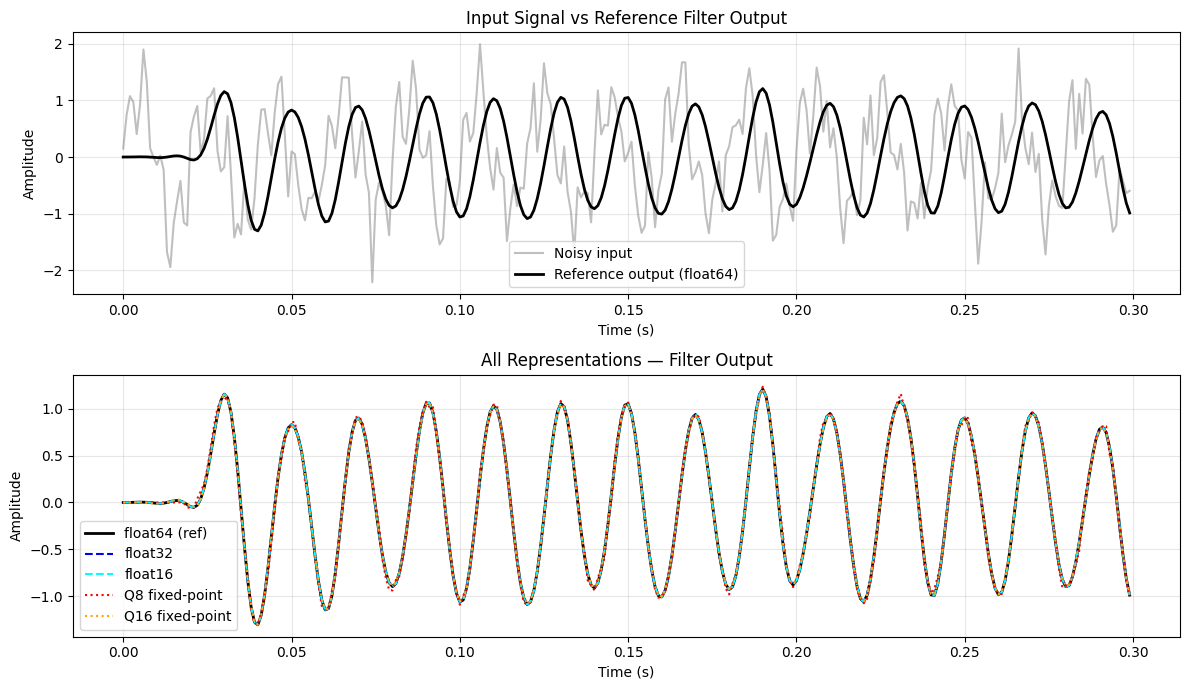

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Input vs reference
ax = axes[0]
ax.plot(t[:300], signal_noisy[:300], label='Noisy input', alpha=0.5, color='gray')
ax.plot(t[:300], ref_output[:300],   label='Reference output (float64)', color='black', linewidth=2)
ax.set_title('Input Signal vs Reference Filter Output')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# All outputs
ax = axes[1]
ax.plot(t[:300], ref_output[:300],   label='float64 (ref)', color='black', linewidth=2)
ax.plot(t[:300], fp32_output[:300],  label='float32',        color='blue',   linestyle='--')
ax.plot(t[:300], fp16_output[:300],  label='float16',        color='cyan',   linestyle='--')
ax.plot(t[:300], fxp8_output[:300],  label='Q8 fixed-point', color='red',    linestyle=':')
ax.plot(t[:300], fxp16_output[:300], label='Q16 fixed-point',color='orange', linestyle=':')
ax.set_title('All Representations — Filter Output')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Error plots for each representation

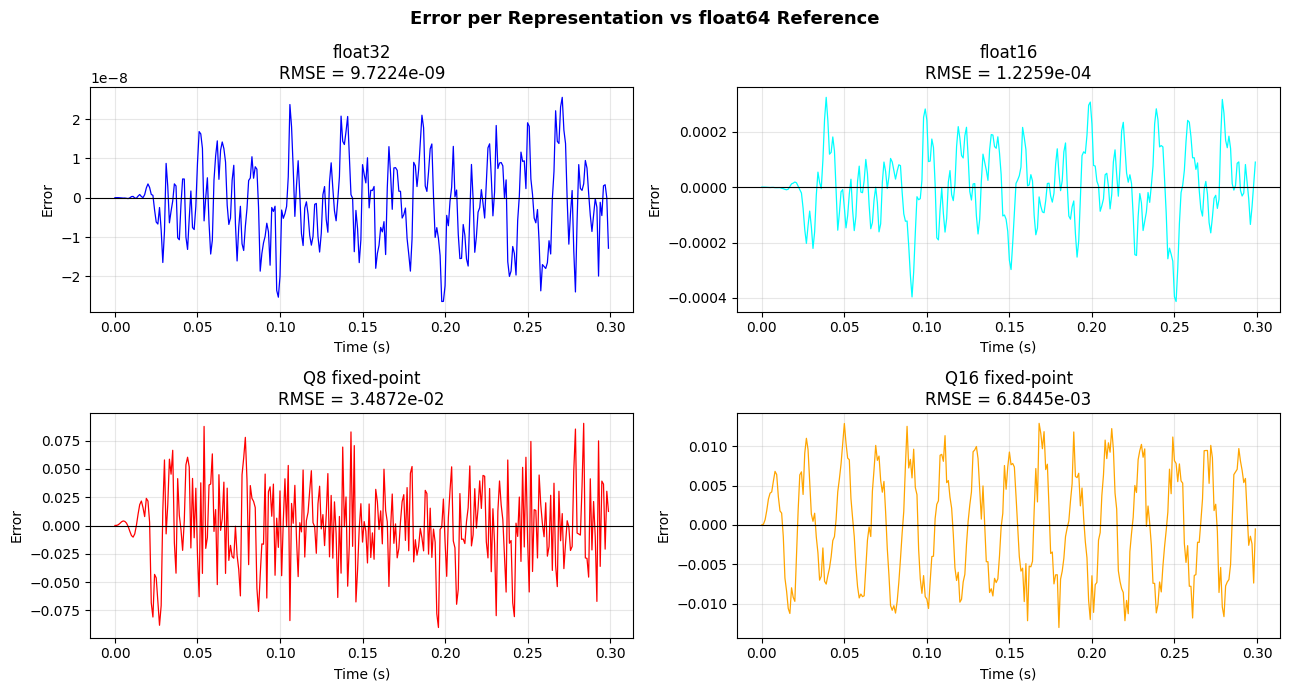

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Error per Representation vs float64 Reference', fontsize=13, fontweight='bold')

configs = [
    (error_fp32,  'float32',         'blue'),
    (error_fp16,  'float16',         'cyan'),
    (error_fxp8,  'Q8 fixed-point',  'red'),
    (error_fxp16, 'Q16 fixed-point', 'orange'),
]

for ax, (err, title, color) in zip(axes.flat, configs):
    ax.plot(t[:300], err[:300], color=color, linewidth=0.9)
    ax.set_title(f'{title}\nRMSE = {rmse(err):.4e}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Error')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Observations

- **float32** has almost zero error (RMSE ~1e-8). It behaves nearly identically to float64.
- **float16** introduces small but visible rounding errors (RMSE ~1e-4) because it only has 10 bits of mantissa.
- **Q8 fixed-point** has the largest error (RMSE ~3.5e-2). With only 4 fractional bits, many decimal values are rounded heavily.
- **Q16 fixed-point** is better than Q8 (RMSE ~6.9e-3) but still clearly worse than any floating-point option.

This shows a clear trade-off: floating-point is more precise, while fixed-point is simpler and cheaper for hardware but introduces more quantization error.